# **PHẦN 5: KIỂM THỬ MÔ HÌNH**
## **1. Định nghĩa vấn đề**
+ **Mô tả**:
   - Đánh giá hiệu suất mô hình trên tập test

## **2. Chuẩn bị vấn đề**

### 2.1. Import các thư viện cần thiết

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.preprocessing import label_binarize
import time
import joblib

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

### 2.2. Lấy tập dữ liệu đã xử lý

In [16]:
x_test = pd.read_parquet("../data_processed/x_test.parquet")
x_test.head()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
228688,-0.408881,-0.369070,0.023915,0.024808,1.274496,0.267549,4.762174,0.422630,0.363827,-0.294921,0.000000,0.00000,0.000000,0.0,-0.431597,0.769709,3.610918,0.0,0.0,0.0,0.0,1,0.000000,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0.500000,8.660254e-01,0.201299,0.979530,0,0,1,0,0,1,0,0,0,1
244685,0.356985,0.000000,-0.570892,-0.592211,0.000000,-0.601360,0.000000,-0.580821,-0.476912,0.631057,0.000000,0.00000,0.000000,0.0,0.044619,-0.220216,0.000000,0.0,0.0,1.0,1.0,0,0.000000,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,-1.000000,-1.836970e-16,0.968077,-0.250653,0,1,0,0,0,0,0,1,0,1
158280,0.196059,0.630930,-0.114178,-0.355326,0.489301,-0.601360,0.000000,-0.281307,-0.031392,-0.079608,0.824203,1.14003,1.184368,1.0,0.354237,0.319545,0.000000,0.0,0.0,1.0,0.0,1,1.439836,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,1,1,0,0,0,1,1,0,1,0,1,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0.866025,5.000000e-01,0.394356,0.918958,0,1,0,0,0,0,1,0,0,0
130374,-0.044289,0.464974,-0.570892,-0.592211,0.000000,0.126472,3.988984,0.035466,0.092650,-0.164827,0.833207,0.00000,0.000000,0.0,0.296265,0.191507,0.000000,0.0,0.0,1.0,1.0,0,0.911983,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,1,0,1,0,0,1,0,0,1,0,1,0,1,1,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,-0.500000,8.660254e-01,0.790776,-0.612106,0,1,0,0,0,0,1,0,0,0
110173,-0.356900,-0.369070,-0.570892,-0.592211,0.000000,-0.601360,0.000000,-0.580821,0.290125,-0.232072,0.000000,0.00000,0.000000,0.0,-0.431597,0.678583,0.000000,0.0,0.0,1.0,1.0,1,0.824235,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,0,1,0,0,1,1,0,1,0,1,1,1,1,0,0,0,1,1,1,1,1,0,1,1,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0.866025,-5.000000e-01,0.724793,0.688967,0,1,0,0,0,0,1,0,0,0


In [17]:
y_test = pd.read_parquet("../data_processed/y_test.parquet")
y_test.head()

,Label
228688,1
244685,1
158280,1
130374,0
110173,0


### 2.3. Đánh giá mô hình trên tập test

In [18]:
loaded_xg_boost = joblib.load("../train/stacking_model.joblib")

In [30]:
start_time = time.time()
    
# predict probability
y_probs = loaded_xg_boost.predict_proba(x_test)

threshold = 0.6
y_pred_custom = []
for prob in y_probs:
    if prob[3] > threshold:
        y_pred_custom.append(3)
    else:
        y_pred_custom.append(np.argmax(prob))

inference_time = time.time() - start_time

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     14745
           1       0.88      0.87      0.88     11708
           2       0.83      0.86      0.84      6739
           3       0.93      0.93      0.93      2371

    accuracy                           0.91     35563
   macro avg       0.90      0.90      0.90     35563
weighted avg       0.91      0.91      0.91     35563



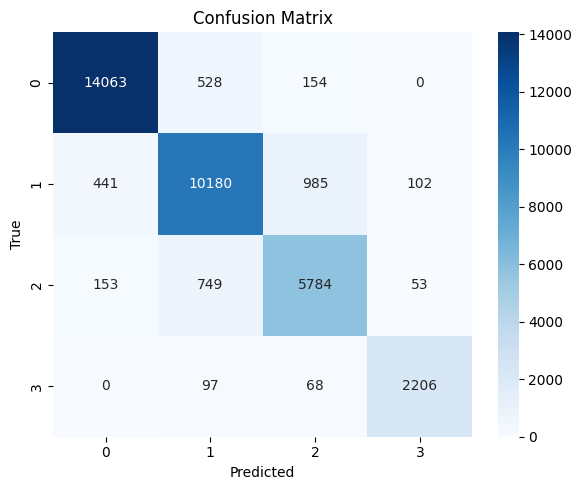

In [21]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,      
    fmt="d",         
    cmap="Blues",
    xticklabels=[0,1,2,3],
    yticklabels=[0,1,2,3]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()

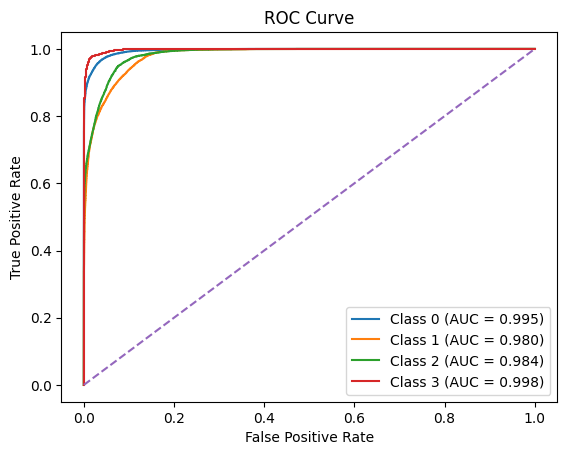

In [33]:
classes=[0, 1, 2, 3]
y_val_bin = label_binarize(y_test, classes=classes)
y_probs = loaded_xg_boost.predict_proba(x_test)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve")
plt.legend()

plt.show()
